In [20]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## 1 Données synthétiques
Considérons le problème de classification binaire représenté en figure 1. Ce problème a été généré
par la fonction make_moons de Scikit-learn.
1. Générez le dataset avec
- 600 données
- un bruit de 0.25

In [54]:
X, y = make_moons(n_samples=600, noise=0.25, random_state=42)

2. affichez le nuage de point pour obtenir le résultat de la figure 

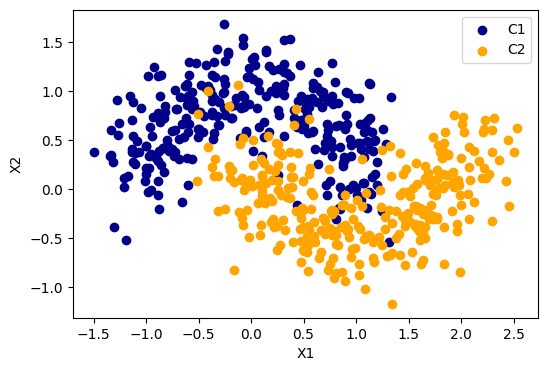

In [55]:
def plot_data():
    plt.figure(figsize=(6, 4))
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='darkblue', label='C1')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='orange', label='C2')
    plt.legend()
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

plot_data()

3. Lancez un apprentissage de 4 SVM sur ces données :
- un SVM linéaire
- un SVM avec noyau RBF
- un SVM avec noyau polynomial
- un SVM avec noyau sigmoid

En dehors des noyaux, utilisez les paramètres par défaut de Scikit-learn

In [56]:
lin = SVC(kernel="linear")
lin.fit(X, y)

rbf = SVC(kernel="rbf")
rbf.fit(X, y)

poly = SVC(kernel="poly")
poly.fit(X, y)

sig = SVC(kernel="sigmoid")
sig.fit(X, y)

SVC(kernel='sigmoid')

4. Affichez les frontières de décision obtenues pour chacun des modèles avec l’ensemble des points et les frontières de marges, comme en figure

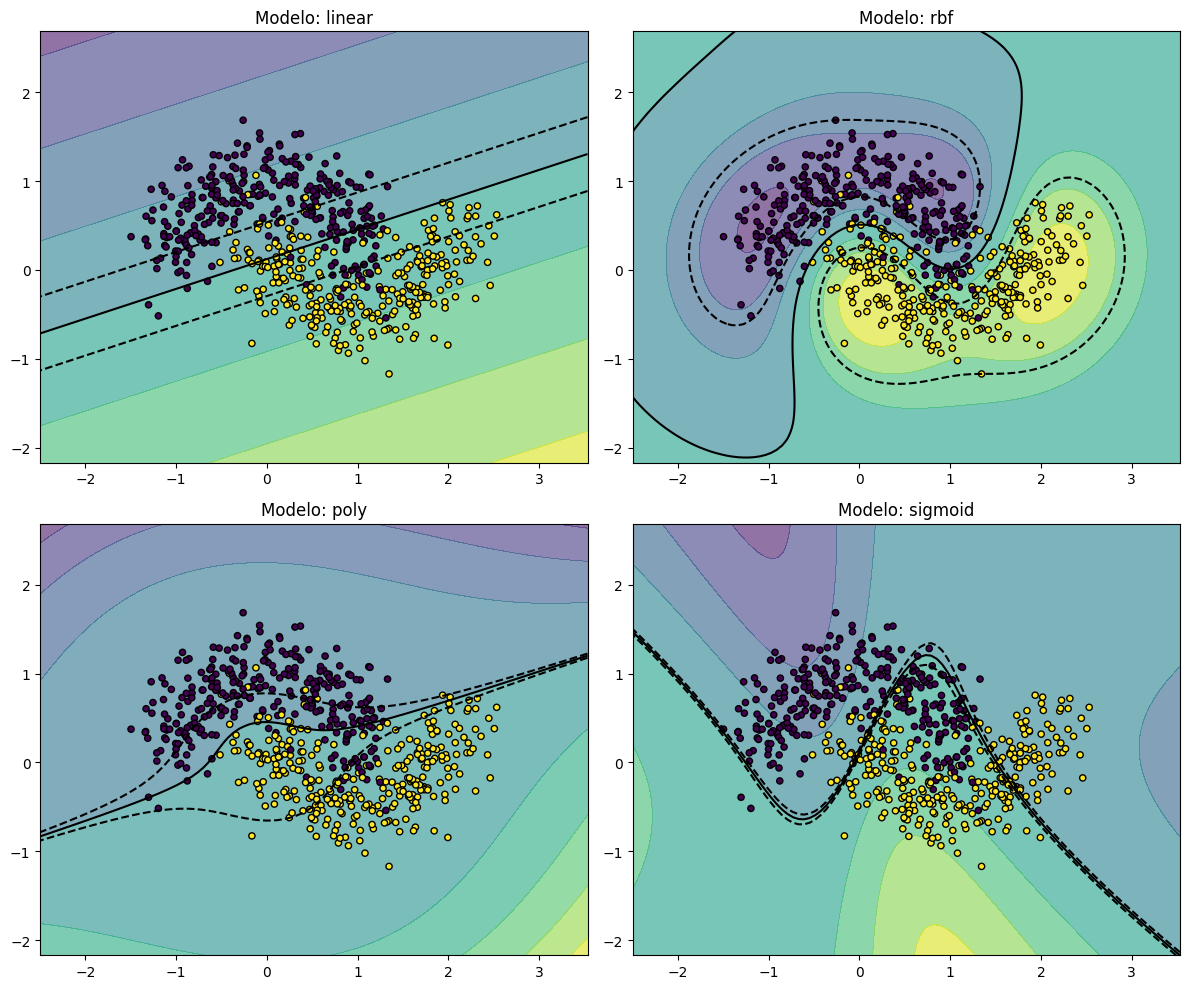

In [58]:
models = [lin, rbf, poly, sig]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, mod in enumerate(models):
    row = i // 2  # row
    col = i % 2   # column
    
    ax = axes[row, col]
    DecisionBoundaryDisplay.from_estimator(mod, X, ax=ax, grid_resolution=1000, alpha=0.6)
    DecisionBoundaryDisplay.from_estimator(mod, X, ax=ax,
                                           response_method="decision_function", plot_method="contour",
                                           levels=[-1, 0, 1], colors=["k", "k", "k"], linestyles=["--", "-", "--"])
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolors='k')
    ax.set_title(f"Model: {mod.get_params()['kernel']}")

plt.tight_layout()
plt.show()


5. Mesurez les performances de ces modèles sur les données d’apprentissage

In [60]:
for mod in models:
    y_pred = mod.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"Accuaracy {mod.get_params()['kernel']} = {acc*100:.2f}%")

Accuaracy linear = 86.33%
Accuaracy rbf = 93.33%
Accuaracy poly = 89.83%
Accuaracy sigmoid = 63.83%


6. Donnez votre analyse des résultats obtenus

## 2 Hyperparamètres du noyau RBF
1. Reprenez le jeu de données précédent et séparez-le en deux sous-ensembles d’apprentissage et de test, de tailles égales

In [61]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print(f"Train: {len(y_train)/len(y)*100:.2f}%")
print(f"Test: {len(y_test)/len(y)*100:.2f}%")

Train: 50.00%
Test: 50.00%


2. Testez toutes les valeurs de paramètres C et γ suivantes :
- C ∈ {0.1, 1, 10}
- γ ∈ {0.01, 0.1, 1, 10, 100}

Pour chaque combinaison de paramètres, entraînez un SVM avec noyau RBF et mesurez la
performance sur l’ensemble de test

In [62]:
Cs = [0.1, 1, 10]
gammas = [0.01, 0.1, 1, 10, 100]
RBFs = []
Accuracy = [] 

for C in Cs:
    for gamma in gammas:
        rbf = SVC(kernel="rbf", C=C, gamma=gamma)
        rbf.fit(x_train, y_train)

        y_pred = rbf.predict(x_test)
        acc = accuracy_score(y_test, y_pred)  
        print(f"Accuaracy (C={C}, γ={gamma}) = {acc*100:.2f}%")
        
        RBFs.append(rbf)
        Accuracy.append(acc)


Accuaracy (C=0.1, γ=0.01) = 78.67%
Accuaracy (C=0.1, γ=0.1) = 81.33%
Accuaracy (C=0.1, γ=1) = 91.33%
Accuaracy (C=0.1, γ=10) = 93.33%
Accuaracy (C=0.1, γ=100) = 88.33%
Accuaracy (C=1, γ=0.01) = 83.00%
Accuaracy (C=1, γ=0.1) = 86.00%
Accuaracy (C=1, γ=1) = 93.00%
Accuaracy (C=1, γ=10) = 93.00%
Accuaracy (C=1, γ=100) = 92.33%
Accuaracy (C=10, γ=0.01) = 85.67%
Accuaracy (C=10, γ=0.1) = 90.00%
Accuaracy (C=10, γ=1) = 93.00%
Accuaracy (C=10, γ=10) = 94.00%
Accuaracy (C=10, γ=100) = 92.00%


3. Sur une même figure composée de 15 sous-figures, affichez les frontières de décision obtenues pour chaque combinaison de paramètres, accompagnées des points de l’ensemble de
test et des frontières de marges

In [35]:
lin.get_params()['gamma']

'scale'

In [47]:
print(RBFs)

[SVC(C=0.1, gamma=0.01), SVC(C=0.1, gamma=0.1), SVC(C=0.1, gamma=1), SVC(C=0.1, gamma=10), SVC(C=0.1, gamma=100), SVC(C=1, gamma=0.01), SVC(C=1, gamma=0.1), SVC(C=1, gamma=1), SVC(C=1, gamma=10), SVC(C=1, gamma=100), SVC(C=10, gamma=0.01), SVC(C=10, gamma=0.1), SVC(C=10, gamma=1), SVC(C=10, gamma=10), SVC(C=10, gamma=100)]


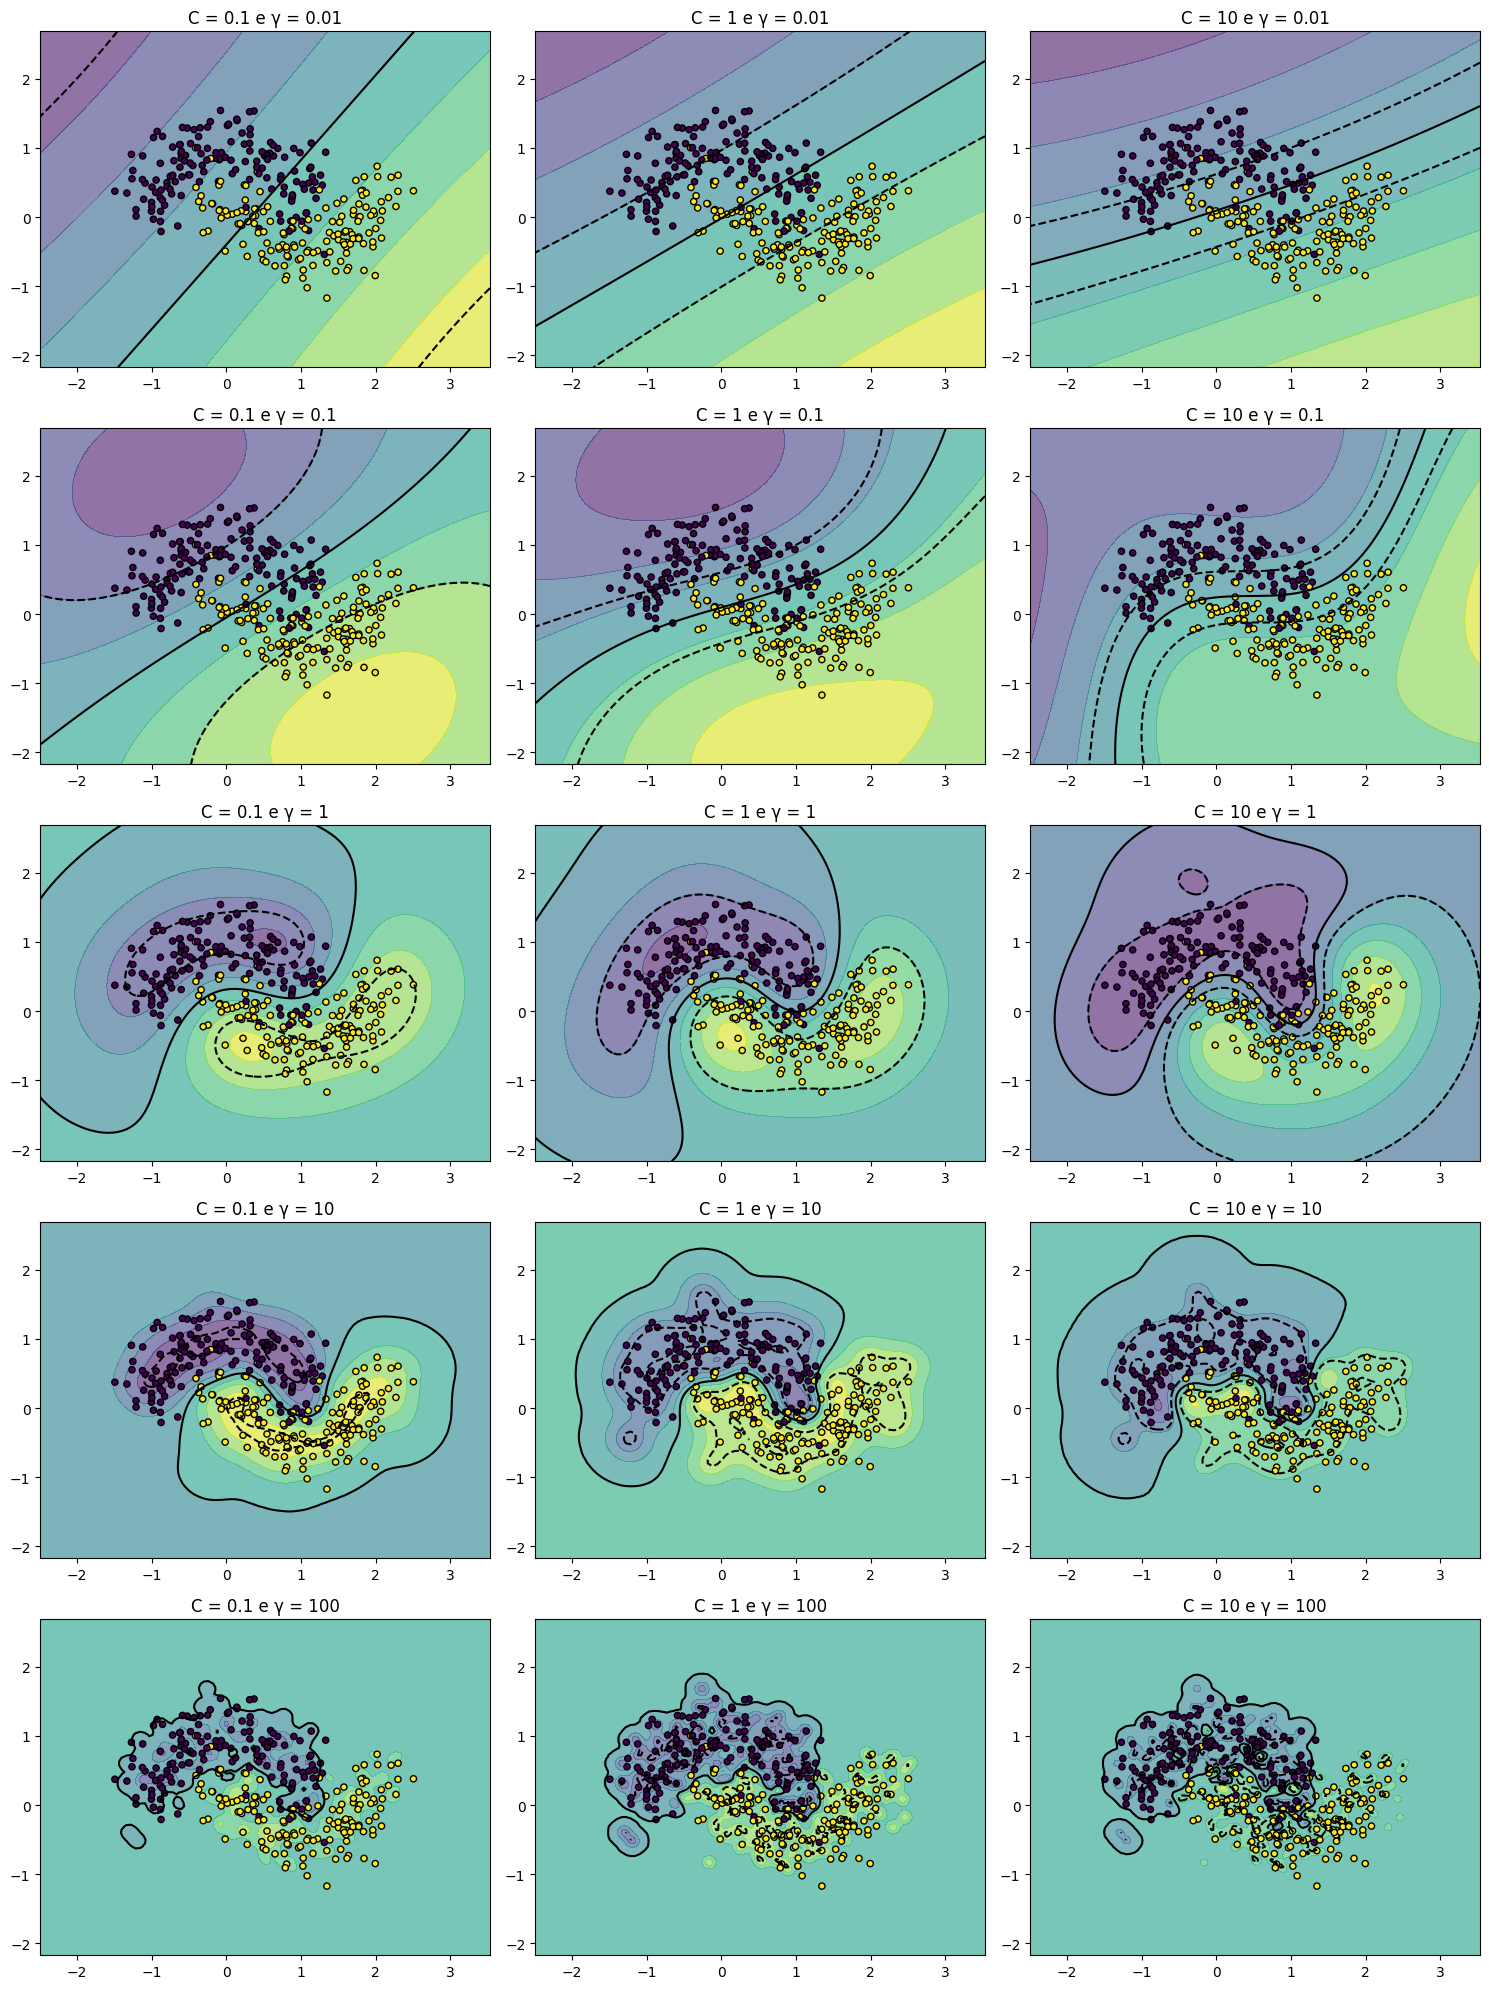

In [63]:
# Criando um grid de 5 linhas e 3 colunas
fig, axes = plt.subplots(5, 3, figsize=(15, 20))

# Iterar sobre os modelos e o grid
for i, mod in enumerate(RBFs):
    row = i % 5  # Linha
    col = i // 5  # Coluna
    
    C_value = mod.get_params()['C']
    gamma_value = mod.get_params()['gamma']
    
    # Obtendo o subgráfico
    ax = axes[row, col]
    
    # Plotando a fronteira de decisão
    DecisionBoundaryDisplay.from_estimator(mod, X, ax=ax, grid_resolution=1000, alpha=0.6)
    DecisionBoundaryDisplay.from_estimator(mod, X, ax=ax,
                                           response_method="decision_function", plot_method="contour",
                                           levels=[-1, 0, 1], colors=["k", "k", "k"], linestyles=["--", "-", "--"])
    
    # Plotando os pontos de teste
    ax.scatter(x_test[:, 0], x_test[:, 1], c=y_test, s=20, edgecolors='k')
    
    # Adicionando título com os parâmetros do modelo
    ax.set_title(f"C = {C_value} e γ = {gamma_value}")

# Ajustando o layout para evitar sobreposição de textos
plt.tight_layout()
plt.show()

4. Donnez votre analyse détaillée des résultats obtenus

5. Nous avons vu en cours que les valeurs optimales des hyperparamètres ne devaient pas être sélectionnées sur l’ensemble de test. Proposez une méthodologie correcte pour trouver les valeurs optimales de C et γ.

In [37]:
x_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {len(y_train)/len(y)*100:.2f}%")
print(f"Valid: {len(y_valid)/len(y)*100:.2f}%")
print(f"Test: {len(y_test)/len(y)*100:.2f}%")

Train: 60.00%
Valid: 20.00%
Test: 20.00%


In [40]:
RBFs = []
bestAcc = 0
bestC = 0
bestGamma = 0

for C in Cs:
    for gamma in gammas:
        rbf = SVC(kernel="rbf", C=vC, gamma=gamma)
        rbf.fit(x_train, y_train)

        y_pred = rbf.predict(x_valid)
        acc = accuracy_score(y_valid, y_pred)  
        print(f"Accuaracy (C={C}, γ={gamma}) = {acc*100:.2f}%")
        
        RBFs.append(rbf)

        if acc > bestAcc:
            bestC = C
            bestGamma = gamma
            bestAcc = acc

print(f"Max Accuaracy Valid: {bestAcc*100:.2f}%")

Accuaracy (C=0.1, γ=0.01) = 84.17%
Accuaracy (C=0.1, γ=0.1) = 91.67%
Accuaracy (C=0.1, γ=1) = 93.33%
Accuaracy (C=0.1, γ=10) = 92.50%
Accuaracy (C=0.1, γ=100) = 86.67%
Accuaracy (C=1, γ=0.01) = 84.17%
Accuaracy (C=1, γ=0.1) = 91.67%
Accuaracy (C=1, γ=1) = 93.33%
Accuaracy (C=1, γ=10) = 92.50%
Accuaracy (C=1, γ=100) = 86.67%
Accuaracy (C=10, γ=0.01) = 84.17%
Accuaracy (C=10, γ=0.1) = 91.67%
Accuaracy (C=10, γ=1) = 93.33%
Accuaracy (C=10, γ=10) = 92.50%
Accuaracy (C=10, γ=100) = 86.67%
Max Accuaracy Valid: 93.33%


6. Quelle est la meilleure combinaison de paramètres ?

In [41]:
print("Best C value:", bestC)
print("Best γ value:", bestGamma)

Best C value: 0.1
Best γ value: 1


7. Quelle est la performance obtenue avec cette combinaison ?

In [43]:
clf = SVC(kernel='rbf', C=bestC, gamma=bestGamma)
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)
acc_SVC = accuracy_score(y_test, y_pred)

print(f"Accuracy = {acc_SVC *100:.2f}%")

Accuracy = 91.67%
